# Задание 4. Деревья решений

Что нужно сделать:
- на датасете «Титаник» обучить `DecisionTreeClassifier` и предсказать целевой столбец `Survived`
  по всем остальным признакам, разбиение 70%/30%;
- сравнить Accuracy деревьев с разными гиперпараметрами: `criterion` (gini / entropy) и `max_depth`;
- получить важности признаков (`feature_importances_`) и нарисовать столбчатую диаграмму;
- обучить вторую модель всего на двух признаках — `Fare` и `Pclass`, построить 2D карту этих признаков
  и границу разделения классов;
- на датасете «Student Exam Score» обучить дерево решений для регрессии и предсказать балл
  (в самом файле непрерывная целевая называется `GPA`), сравнить MAE / RMSE / R² по гиперпараметрам,
  построить график «прогноз против истины» и важности признаков.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)

np.random.seed(42)

## Часть 1. Дерево решений для классификации (датасет «Титаник»)

### Шаг 1. Загружаем данные и смотрим на них

Файл `titanic.csv` — это привычный вариант датасета «Титаник» на 891 пассажира. Кагловский «test-file»
из условия имеет ровно тот же набор столбцов, отличается только объемом выборки, поэтому весь код ниже
подходит и к нему.

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# смотрим, где пропуски
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# баланс классов: выживших заметно меньше, но перекос не критичный
print(df["Survived"].value_counts())
print()
print(df["Survived"].value_counts(normalize=True).round(3))

Survived
0    549
1    342
Name: count, dtype: int64

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


Пропуски есть в трех столбцах: `Age` — 177 значений (20% выборки), `Cabin` — 687 (почти 77%),
`Embarked` — 2. Классы несбалансированы умеренно: 549 не выживших против 342 выживших (62% / 38%),
то есть модель, которая всем ставит «не выжил», дала бы accuracy 0.62 — это ориентир, с которым
дальше сравниваем дерево.

### Шаг 2. Готовим признаки

Дерево умеет работать только с числами, поэтому текстовые столбцы нужно либо закодировать, либо выбросить:

- `PassengerId`, `Name`, `Ticket` — **выбрасываем**. Это идентификаторы: они уникальны почти для каждой
  строки, никакой закономерности «выжил / не выжил» в номере билета нет, а дерево по такому признаку
  просто запомнит обучающую выборку.
- `Cabin` — пропущен у 77% пассажиров, восстановить его нечем. Но сам факт, что номер каюты записан,
  информативен (каюты фиксировали в основном у пассажиров 1 класса), поэтому вместо номера делаем
  бинарный признак `Cabin_known` — известна каюта или нет.
- `Sex` — кодируем числами: male = 0, female = 1.
- `Embarked` — 2 пропуска заполняем самым частым портом (`S`), потом кодируем: S = 0, C = 1, Q = 2.
- `Age` — пропуски заполняем медианой, но медиану считаем **только по обучающей выборке** (после
  разбиения), чтобы информация из теста не попала в обучение.

In [7]:
data = df.copy()

# каюта известна / не известна — вместо самого номера каюты
data["Cabin_known"] = data["Cabin"].notnull().astype(int)

# идентификаторы и исходный Cabin убираем
data = data.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# текстовые признаки в числа
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data["Embarked"] = data["Embarked"].fillna("S").map({"S": 0, "C": 1, "Q": 2})

data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_known
0,0,3,0,22.0,1,0,7.2500,0,0
1,1,1,1,38.0,1,0,71.2833,1,1
2,1,3,1,26.0,0,0,7.9250,0,0
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,0


### Шаг 3. Делим выборку на обучающую и тестовую 70% / 30%

In [8]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# медиану возраста берем по обучающей выборке и ей же заполняем тест
age_median = X_train["Age"].median()
X_train = X_train.fillna({"Age": age_median})
X_test = X_test.fillna({"Age": age_median})

print("медиана Age по обучающей выборке =", age_median)
print("обучающая:", X_train.shape, " тестовая:", X_test.shape)
print("пропусков осталось:", X_train.isnull().sum().sum() + X_test.isnull().sum().sum())

медиана Age по обучающей выборке = 29.0
обучающая: (623, 8)  тестовая: (268, 8)
пропусков осталось: 0


### Шаг 4. Обучаем дерево решений

Сначала обучим дерево с настройками по умолчанию, то есть без ограничения глубины — оно будет расти,
пока не разложит обучающую выборку по листьям идеально.

In [9]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

print("глубина выросшего дерева =", tree.get_depth())
print("accuracy на обучающей =", accuracy_score(y_train, tree.predict(X_train)))
print("accuracy на тестовой  =", accuracy_score(y_test, tree.predict(X_test)))

глубина выросшего дерева = 21
accuracy на обучающей = 0.9791332263242376
accuracy на тестовой  = 0.7686567164179104


Дерево выросло на 21 уровень и почти наизусть выучило обучающую выборку (accuracy 0.979), а на тесте
дало всего 0.769. Разрыв в 21 процентный пункт — это переобучение, значит глубину надо ограничивать.

### Шаг 5. Сравниваем гиперпараметры: criterion и max_depth

`criterion` — чем измеряем «беспорядок» в узле при выборе разбиения (gini или entropy),
`max_depth` — сколько уровней разрешаем дереву. Перебираем все комбинации: 2 критерия на глубины 1..15,
и для каждой считаем accuracy на обучающей и тестовой выборках.

In [10]:
rows = []

for criterion in ["gini", "entropy"]:
    for depth in range(1, 16):
        model = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        rows.append({
            "criterion": criterion,
            "max_depth": depth,
            "acc_train": accuracy_score(y_train, model.predict(X_train)),
            "acc_test": accuracy_score(y_test, model.predict(X_test)),
        })

res = pd.DataFrame(rows)
res.round(3)

,criterion,max_depth,acc_train,acc_test
0,gini,1,0.791,0.776
1,gini,2,0.807,0.769
2,gini,3,0.830,0.795
3,gini,4,0.851,0.802
4,gini,5,0.864,0.769
5,gini,6,0.878,0.772
6,gini,7,0.900,0.772
7,gini,8,0.920,0.769
8,gini,9,0.926,0.772
9,gini,10,0.936,0.776


In [11]:
# та же таблица, но компактно: accuracy на тесте, по строкам глубина, по столбцам критерий
res.pivot(index="max_depth", columns="criterion", values="acc_test").round(3)

criterion,entropy,gini
max_depth,,
1,0.776,0.776
2,0.776,0.769
3,0.791,0.795
4,0.802,0.802
5,0.799,0.769
6,0.769,0.772
7,0.780,0.772
8,0.784,0.769
9,0.791,0.772


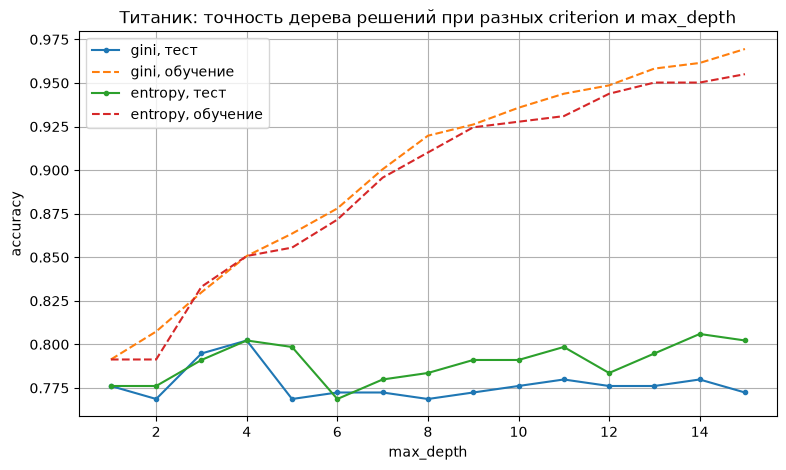

In [12]:
plt.figure(figsize=(9, 5))

for criterion in ["gini", "entropy"]:
    part = res[res["criterion"] == criterion]
    plt.plot(part["max_depth"], part["acc_test"], marker=".", label=criterion + ", тест")
    plt.plot(part["max_depth"], part["acc_train"], linestyle="--", label=criterion + ", обучение")

plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Титаник: точность дерева решений при разных criterion и max_depth")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# формальный максимум по тестовой выборке
print(res.sort_values("acc_test", ascending=False).head(5).round(3))

   criterion  max_depth  acc_train  acc_test
28   entropy         14      0.950     0.806
29   entropy         15      0.955     0.802
3       gini          4      0.851     0.802
18   entropy          4      0.851     0.802
25   entropy         11      0.931     0.799


Обучающие кривые (пунктир) растут монотонно — с глубиной дерево все лучше подгоняется под обучающие
данные и к `max_depth = 15` доходит до 0.95-0.97. А тестовые кривые ведут себя иначе: они поднимаются
до `max_depth = 4` (accuracy 0.802 у обоих критериев), потом падают до 0.77 и дальше только колеблются
в коридоре 0.77-0.81. Это и есть переобучение: глубокие уровни дерева уже не находят общие
закономерности, а разбивают выборку на мелкие листья по случайным особенностям конкретных пассажиров.

Формальный максимум accuracy — 0.806 у `entropy` с `max_depth = 14`, но он выше результата
`max_depth = 4` всего на 0.004 (одного пассажира из 268), при этом дерево втрое глубже и разрыв с
обучающей выборкой 0.15 против 0.05. Такая разница — это шум конкретного разбиения, поэтому **лучшей
моделью считаем `criterion = entropy`, `max_depth = 4`**: та же точность при более простом дереве.
Выбор критерия почти ни на что не влияет — gini и entropy идут рядом, на малых глубинах вообще
совпадают.

### Шаг 6. Метрики и матрица ошибок лучшей модели

In [14]:
best_tree = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
best_tree.fit(X_train, y_train)
pred = best_tree.predict(X_test)

print("Accuracy  =", accuracy_score(y_test, pred))
print("Precision =", precision_score(y_test, pred))
print("Recall    =", recall_score(y_test, pred))
print("F1        =", f1_score(y_test, pred))

Accuracy  = 0.8022388059701493
Precision = 0.8571428571428571
Recall    = 0.5825242718446602
F1        = 0.6936416184971098


In [15]:
# матрица ошибок: по строкам правильные ответы, по столбцам прогноз
cm = confusion_matrix(y_test, pred)
pd.DataFrame(cm, index=["не выжил", "выжил"], columns=["не выжил", "выжил"])

,не выжил,выжил
не выжил,155,10
выжил,43,60


Accuracy = 0.802 против 0.62 у «всем не выжил» — модель действительно чему-то научилась.
Но precision (0.857) и recall (0.583) сильно разошлись: из 103 выживших в тесте модель нашла только 60,
а 43 записала в погибших. Ошибки несимметричны — 43 пропущенных выживших против 10 ложных срабатываний,
и причина в дисбалансе классов: класс «не выжил» больше, поэтому дереву выгоднее ставить его в спорных
листьях.

### Шаг 7. Важность признаков

In [16]:
importances = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.round(3)

Sex            0.513
Age            0.150
Pclass         0.138
Fare           0.099
Cabin_known    0.091
Parch          0.009
SibSp          0.000
Embarked       0.000
dtype: float64

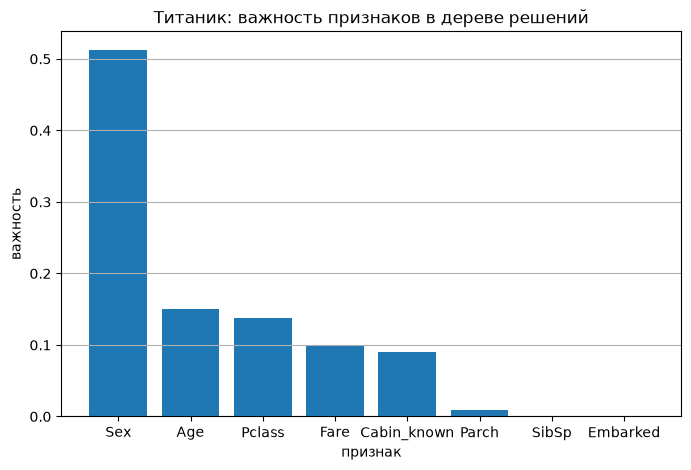

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(importances.index, importances.values)
plt.xlabel("признак")
plt.ylabel("важность")
plt.title("Титаник: важность признаков в дереве решений")
plt.grid(True, axis="y")
plt.show()

Больше половины важности (0.51) забрал пол пассажира — женщин спасали в первую очередь, и это самое
сильное правило в датасете. Дальше идут `Age` (0.15), `Pclass` (0.14) и `Fare` (0.10): дети имели
преимущество, а класс каюты и стоимость билета говорят об одном и том же — богатые пассажиры с верхних
палуб выбирались чаще. `Cabin_known` набрал 0.09, то есть придуманный признак «каюта известна»
оказался полезнее, чем `SibSp`, `Parch` и `Embarked`, важность которых практически нулевая.

### Шаг 8. Вторая модель: только два признака Fare и Pclass

Теперь обучим отдельное дерево всего на двух признаках — стоимости билета и классе каюты. Двух
признаков хватает, чтобы нарисовать карту и увидеть границу разделения классов. Глубину берем
небольшую (`max_depth = 4`), иначе граница распадется на множество узких полосок.

In [18]:
X2 = data[["Fare", "Pclass"]]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.3, random_state=42, stratify=y)

tree2 = DecisionTreeClassifier(max_depth=4, random_state=42)
tree2.fit(X2_train, y2_train)

print("accuracy на тесте (2 признака) =", accuracy_score(y2_test, tree2.predict(X2_test)))

accuracy на тесте (2 признака) = 0.6902985074626866


In [19]:
# покрываем плоскость сеткой и прогоняем через модель — так видно границу
xx, yy = np.meshgrid(np.arange(-5, X2["Fare"].max() + 10, 1.0),
                     np.arange(0.5, 3.6, 0.02))
grid = pd.DataFrame({"Fare": xx.ravel(), "Pclass": yy.ravel()})
zz = tree2.predict(grid).reshape(xx.shape)

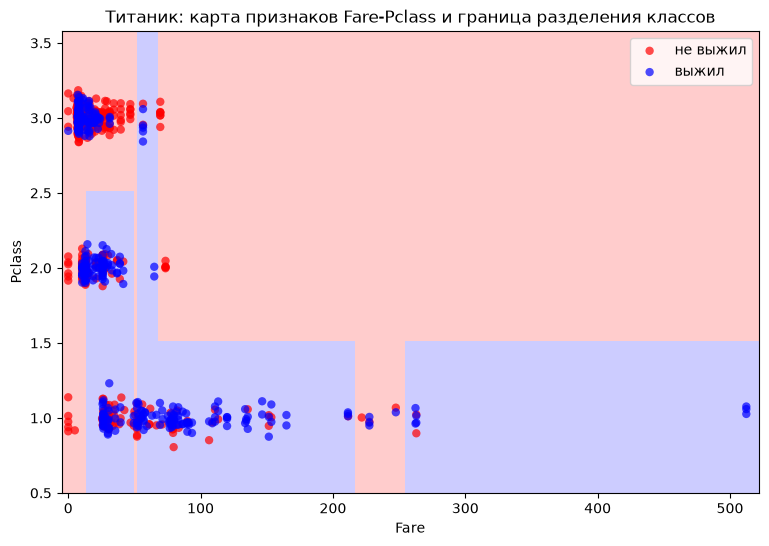

In [20]:
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["#ffcccc", "#ccccff"])

# Pclass принимает всего 3 значения, поэтому точки добавляем с небольшим разбросом по вертикали,
# иначе они лежат в три линии друг на друге
jitter = np.random.normal(0, 0.06, len(X2))

for cls, color, name in [(0, "red", "не выжил"), (1, "blue", "выжил")]:
    mask = (y == cls).values
    plt.scatter(X2["Fare"][mask], X2["Pclass"][mask] + jitter[mask],
                c=color, label=name, edgecolors="none", alpha=0.7)

plt.xlabel("Fare")
plt.ylabel("Pclass")
plt.title("Титаник: карта признаков Fare-Pclass и граница разделения классов")
plt.legend()
plt.show()

Граница у дерева всегда состоит из прямых отрезков, параллельных осям, — модель умеет делать только
разрезы вида «признак меньше порога». Видно, что она нашла: пассажиры 1 класса (Pclass = 1) почти
целиком попали в синюю область «выжил», а 2 и 3 класс — в красную, кроме узких синих полос дорогих
билетов, которые дерево выделило отдельными разрезами: во 2 классе это Fare примерно от 13.5 до 50,
в 3 классе — от 52 до 67.

Точность на двух признаках — 0.690, это ниже, чем 0.802 на всех признаках: мы выбросили самый важный
признак `Sex`. Заодно понятно, почему на карте столько красных и синих точек друг на друге — по цене
и классу билета выживших и погибших не разделить, внутри каждого класса каюты есть и те, и другие.

**Вывод по части 1.** Дерево решений на «Титанике» дает accuracy около 0.80 против 0.62 у тривиального
прогноза. Главный гиперпараметр — `max_depth`: оптимум приходится на 4 уровня, а без ограничения
дерево доходит до глубины 21, выучивает обучающую выборку на 0.98 и теряет на тесте 3-4 процентных
пункта. `criterion` (gini или entropy) практически не влияет на результат. Самый информативный признак —
пол пассажира (важность 0.51), затем возраст, класс каюты и стоимость билета; порт погрузки и число
родственников на борту оказались бесполезны.

## Часть 2. Дерево решений для регрессии (датасет «Student Exam Score»)

В условии целевой столбец назван «Exam score», но в самом файле датасета такого столбца нет:
непрерывный признак успеваемости здесь называется `GPA` (средний балл от 0.0 до 4.0) — его и прогнозируем.

### Шаг 1. Загружаем данные и смотрим на них

In [21]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
# в имени файла есть пробел перед .csv — так он и лежит в датасете
df2 = pd.read_csv("Student_performance_data _.csv")
df2.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [23]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [24]:
# пропуски и дубликаты
print("пропусков:", df2.isnull().sum().sum())
print("дубликатов строк:", df2.duplicated().sum())

пропусков: 0
дубликатов строк: 0


In [25]:
df2.describe().round(2)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.00,2392.0,2392.00,2392.00,2392.00
mean,2196.50,16.47,0.51,0.88,1.75,9.77,14.54,0.30,2.12,0.38,0.30,0.2,0.16,1.91,2.98
std,690.66,1.12,0.50,1.03,1.00,5.65,8.47,0.46,1.12,0.49,0.46,0.4,0.36,0.92,1.23
min,1001.00,15.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,1598.75,15.00,0.00,0.00,1.00,5.04,7.00,0.00,1.00,0.00,0.00,0.0,0.00,1.17,2.00
50%,2196.50,16.00,1.00,0.00,2.00,9.71,15.00,0.00,2.00,0.00,0.00,0.0,0.00,1.89,4.00
75%,2794.25,17.00,1.00,2.00,2.00,14.41,22.00,1.00,3.00,1.00,1.00,0.0,0.00,2.62,4.00
max,3392.00,18.00,1.00,3.00,4.00,19.98,29.00,1.00,4.00,1.00,1.00,1.0,1.00,4.00,4.00


In [26]:
# смотрим, как признаки связаны с целевым GPA
df2.corr(numeric_only=True)["GPA"].sort_values().round(3)

Absences            -0.919
GradeClass          -0.783
ParentalEducation   -0.036
Gender              -0.013
StudentID           -0.003
Age                  0.000
Volunteering         0.003
Ethnicity            0.028
Sports               0.058
Music                0.073
Extracurricular      0.094
Tutoring             0.145
StudyTimeWeekly      0.179
ParentalSupport      0.191
GPA                  1.000
Name: GPA, dtype: float64

Данные чистые: 2392 студента, 15 столбцов, все числовые, пропусков и дубликатов нет — кодировать и
заполнять ничего не нужно. Целевой `GPA` лежит в диапазоне 0.0-4.0 со средним 1.91.

По корреляциям сразу видно два столбца, которые связаны с `GPA` очень сильно: `Absences`
(пропуски занятий, -0.919) и `GradeClass` (-0.783). Остальные признаки слабые, у них корреляция
не выше 0.19 по модулю.

### Шаг 2. Готовим признаки

Из входных признаков выбрасываем два столбца:

- `StudentID` — это идентификатор студента, номер в базе. Никакой закономерности в нем нет, дерево
  по такому признаку просто запомнит обучающую выборку.
- `GradeClass` — **утечка целевой переменной**. Это буквенная категория оценки (0 = A, 1 = B, ... 4 = F),
  которую поставили по тому же самому среднему баллу, то есть она получена *из* `GPA`, а не измерена
  независимо. Отсюда и корреляция -0.783. Если оставить ее в признаках, дерево будет прогнозировать
  оценку по оценке: метрики выйдут красивыми, но на новых студентах, у которых `GradeClass` еще нет,
  модель работать не сможет.

`Absences` при этом оставляем, хотя корреляция у него еще выше (-0.919). Это не утечка: пропуски
занятий — независимо измеренная величина и причина низкого балла, а не его следствие.

In [27]:
X_reg = df2.drop(["StudentID", "GradeClass", "GPA"], axis=1)
y_reg = df2["GPA"]

print("признаков:", X_reg.shape[1])
print(list(X_reg.columns))

признаков: 12
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']


### Шаг 3. Делим выборку на обучающую и тестовую 70% / 30%

In [28]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)

print("обучающая:", Xr_train.shape, " тестовая:", Xr_test.shape)

обучающая: (1674, 12)  тестовая: (718, 12)


### Шаг 4. Обучаем дерево регрессии

Как и в первой части, сначала дерево без ограничения глубины — посмотрим, насколько оно переобучается.

In [29]:
reg = DecisionTreeRegressor(random_state=42)
reg.fit(Xr_train, yr_train)

print("глубина выросшего дерева =", reg.get_depth())
print("R2 на обучающей =", round(r2_score(yr_train, reg.predict(Xr_train)), 3))
print("R2 на тестовой  =", round(r2_score(yr_test, reg.predict(Xr_test)), 3))
print("MAE на тестовой =", round(mean_absolute_error(yr_test, reg.predict(Xr_test)), 3))

глубина выросшего дерева = 19
R2 на обучающей = 1.0
R2 на тестовой  = 0.85
MAE на тестовой = 0.28


Дерево выросло на 19 уровней, на обучающей выборке R2 = 1.0 (в каждом листе по одному студенту), а на
тесте только 0.85 при MAE 0.28. Переобучение то же, что и в части 1, — глубину надо ограничивать.

### Шаг 5. Сравниваем гиперпараметры: criterion и max_depth

Для регрессии `criterion` — это функция потерь, по которой дерево выбирает разбиение: `squared_error`
(дисперсия в узле), `absolute_error` (медианное отклонение) и `poisson` (для неотрицательных величин).
Четвертый вариант из документации, `friedman_mse`, в текущей версии sklearn (1.9) объявлен устаревшим
и полностью совпадает со `squared_error`, поэтому в перебор его не берем.

Перебираем 3 критерия на глубины 1..15 и для каждой комбинации считаем MAE, RMSE и R2 на тесте
(плюс R2 на обучении, чтобы видеть переобучение).

In [30]:
rows = []

for criterion in ["squared_error", "absolute_error", "poisson"]:
    for depth in range(1, 16):
        model = DecisionTreeRegressor(criterion=criterion, max_depth=depth, random_state=42)
        model.fit(Xr_train, yr_train)
        pred_test = model.predict(Xr_test)
        rows.append({
            "criterion": criterion,
            "max_depth": depth,
            "MAE": mean_absolute_error(yr_test, pred_test),
            "RMSE": np.sqrt(mean_squared_error(yr_test, pred_test)),
            "R2": r2_score(yr_test, pred_test),
            "R2_train": r2_score(yr_train, model.predict(Xr_train)),
        })

res_reg = pd.DataFrame(rows)
res_reg.round(3)

,criterion,max_depth,MAE,RMSE,R2,R2_train
0,squared_error,1,0.463,0.560,0.628,0.640
1,squared_error,2,0.333,0.420,0.791,0.797
2,squared_error,3,0.307,0.382,0.827,0.843
3,squared_error,4,0.281,0.352,0.853,0.876
4,squared_error,5,0.264,0.326,0.874,0.898
5,squared_error,6,0.250,0.314,0.883,0.920
6,squared_error,7,0.243,0.308,0.888,0.940
7,squared_error,8,0.247,0.314,0.883,0.960
8,squared_error,9,0.254,0.322,0.877,0.975
9,squared_error,10,0.262,0.335,0.866,0.985


In [31]:
# та же таблица компактно: R2 на тесте, по строкам глубина, по столбцам критерий
res_reg.pivot(index="max_depth", columns="criterion", values="R2").round(3)

criterion,absolute_error,poisson,squared_error
max_depth,,,
1,0.627,0.619,0.628
2,0.791,0.792,0.791
3,0.826,0.837,0.827
4,0.851,0.857,0.853
5,0.866,0.878,0.874
6,0.872,0.888,0.883
7,0.876,0.890,0.888
8,0.865,0.885,0.883
9,0.868,0.879,0.877


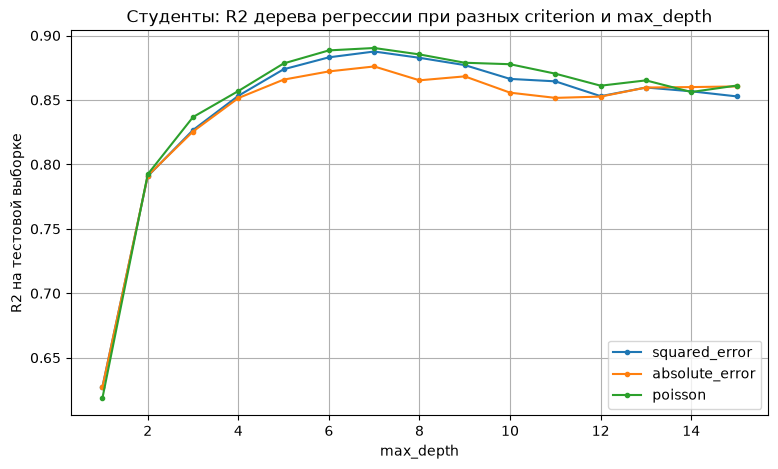

In [32]:
plt.figure(figsize=(9, 5))

for criterion in ["squared_error", "absolute_error", "poisson"]:
    part = res_reg[res_reg["criterion"] == criterion]
    plt.plot(part["max_depth"], part["R2"], marker=".", label=criterion)

plt.xlabel("max_depth")
plt.ylabel("R2 на тестовой выборке")
plt.title("Студенты: R2 дерева регрессии при разных criterion и max_depth")
plt.legend()
plt.grid(True)
plt.show()

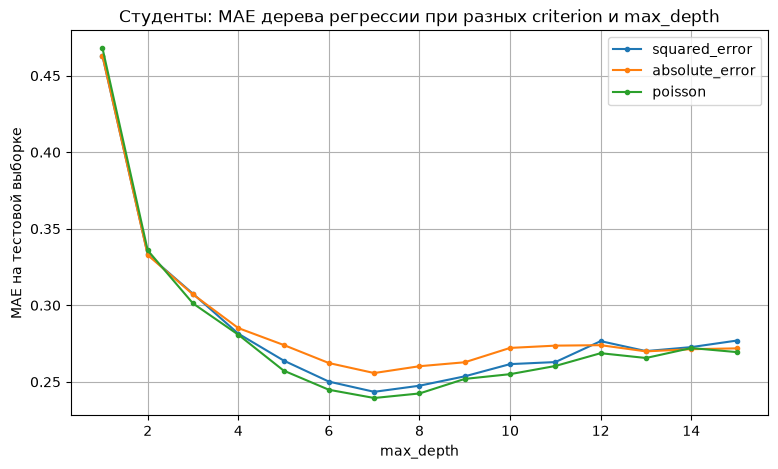

In [33]:
plt.figure(figsize=(9, 5))

for criterion in ["squared_error", "absolute_error", "poisson"]:
    part = res_reg[res_reg["criterion"] == criterion]
    plt.plot(part["max_depth"], part["MAE"], marker=".", label=criterion)

plt.xlabel("max_depth")
plt.ylabel("MAE на тестовой выборке")
plt.title("Студенты: MAE дерева регрессии при разных criterion и max_depth")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# лучшие комбинации по R2 на тесте
res_reg.sort_values("R2", ascending=False).head(5).round(3)

,criterion,max_depth,MAE,RMSE,R2,R2_train
36,poisson,7,0.239,0.304,0.890,0.936
35,poisson,6,0.245,0.306,0.888,0.918
6,squared_error,7,0.243,0.308,0.888,0.940
37,poisson,8,0.242,0.311,0.885,0.954
5,squared_error,6,0.250,0.314,0.883,0.920


Обе кривые ведут себя одинаково: до `max_depth = 7` R2 растет, а MAE падает, после этого R2 идет вниз
(с 0.89 до 0.85-0.86), а MAE снова растет. Причина в столбце `R2_train`: на обучающей выборке R2
монотонно доходит до 1.0, то есть глубокие уровни дерева уже не находят общих закономерностей,
а разрезают выборку на крошечные листья под конкретных студентов.

Выбор критерия почти не влияет: на оптимальной глубине 7 у `poisson` R2 = 0.890, у `squared_error`
0.888, у `absolute_error` 0.876. Лучшая модель — **`criterion = poisson`, `max_depth = 7`**, но выигрыш
у нее в пределах шума.

### Шаг 6. Метрики лучшей модели

In [35]:
best_reg = DecisionTreeRegressor(criterion="poisson", max_depth=7, random_state=42)
best_reg.fit(Xr_train, yr_train)
pred_reg = best_reg.predict(Xr_test)

print("MAE  =", round(mean_absolute_error(yr_test, pred_reg), 3))
print("MSE  =", round(mean_squared_error(yr_test, pred_reg), 3))
print("RMSE =", round(np.sqrt(mean_squared_error(yr_test, pred_reg)), 3))
print("R2   =", round(r2_score(yr_test, pred_reg), 3))

MAE  = 0.239
MSE  = 0.092
RMSE = 0.304
R2   = 0.89


Модель объясняет 89% разброса среднего балла, средняя ошибка 0.24 балла при диапазоне `GPA` 0-4 —
то есть примерно 6% шкалы. RMSE (0.304) заметно больше MAE (0.239), значит есть отдельные студенты
с крупными промахами, которые и тянут квадратичную ошибку вверх.

### Шаг 7. График «прогноз против истины»

По горизонтальной оси — прогноз модели, по вертикальной — истинный `GPA`. Пунктиром нарисована
диагональ y = x: чем ближе точки к ней, тем точнее прогноз.

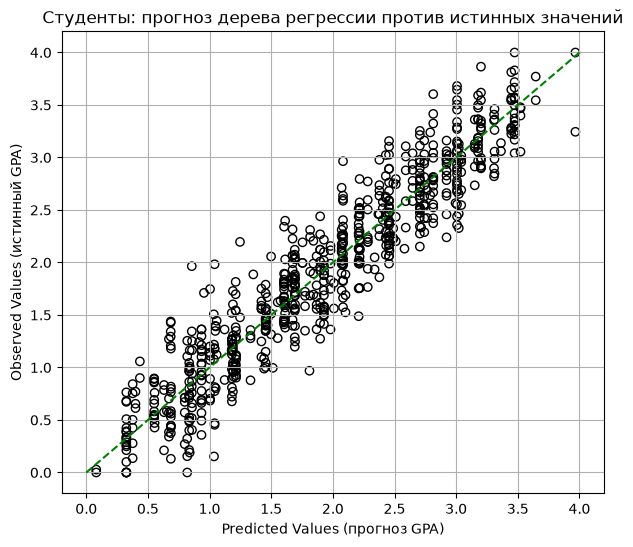

In [36]:
plt.figure(figsize=(7, 6))
plt.scatter(pred_reg, yr_test, facecolors="none", edgecolors="black")

# диагональ y = x — идеальный прогноз
line = [min(pred_reg.min(), yr_test.min()), max(pred_reg.max(), yr_test.max())]
plt.plot(line, line, "g--")

plt.xlabel("Predicted Values (прогноз GPA)")
plt.ylabel("Observed Values (истинный GPA)")
plt.title("Студенты: прогноз дерева регрессии против истинных значений")
plt.grid(True)
plt.show()

Точки лежат узкой полосой вокруг диагонали по всему диапазону от 0 до 4 — систематического смещения
нет, модель не занижает и не завышает балл. Заметно только, что прогнозы выстраиваются в вертикальные
полоски: дерево выдает не любое число, а среднее по листу, и разных значений в прогнозе всего
столько, сколько листьев у дерева (126).

### Шаг 8. Важность признаков

In [37]:
importances_reg = pd.Series(best_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)
importances_reg.round(3)

Absences             0.875
StudyTimeWeekly      0.057
ParentalSupport      0.037
Tutoring             0.012
Sports               0.006
Extracurricular      0.006
Music                0.002
ParentalEducation    0.002
Age                  0.001
Volunteering         0.001
Ethnicity            0.000
Gender               0.000
dtype: float64

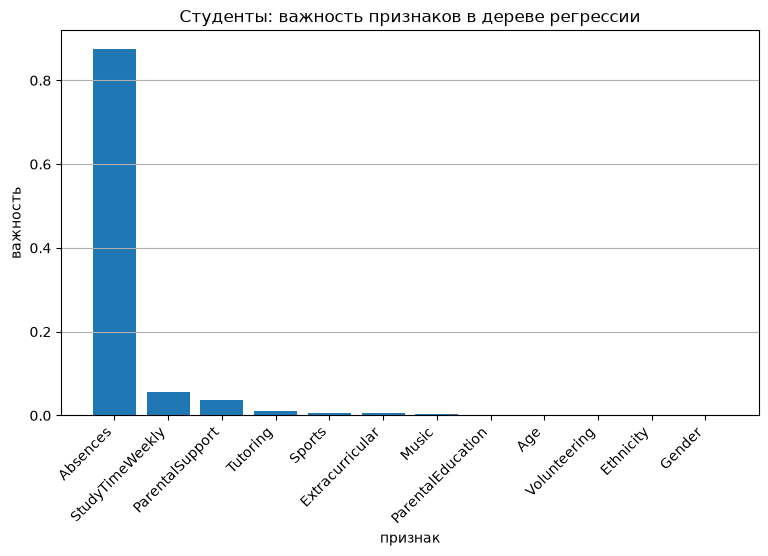

In [38]:
plt.figure(figsize=(9, 5))
plt.bar(importances_reg.index, importances_reg.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("признак")
plt.ylabel("важность")
plt.title("Студенты: важность признаков в дереве регрессии")
plt.grid(True, axis="y")
plt.show()

Почти вся важность (0.875) у `Absences` — числа пропущенных занятий; это согласуется с корреляцией
-0.919, посещаемость определяет средний балл сильнее всего остального вместе. Дальше с большим отрывом
идут `StudyTimeWeekly` (0.057, часы самостоятельных занятий в неделю), `ParentalSupport` (0.037) и
`Tutoring` (0.012) — то есть учеба и поддержка тоже работают, но их вклад в разы меньше. Признаки
`Gender`, `Ethnicity`, `Age` и `Volunteering` получили около нуля: на балл они не влияют.

**Вывод по части 2.** Дерево регрессии прогнозирует средний балл с MAE = 0.239, RMSE = 0.304 и
R2 = 0.890. Как и в классификации, главный гиперпараметр — `max_depth` с оптимумом на 7 уровнях:
без ограничения дерево доходит до глубины 19, выучивает обучающую выборку на R2 = 1.0 и теряет на
тесте 0.04. `criterion` почти не влияет. Отдельно важно, что из признаков пришлось убрать
`GradeClass`: он посчитан из того же `GPA` и дал бы утечку целевой переменной.

**Общий вывод по заданию.** На обоих датасетах дерево решений работает и в задаче классификации
(Accuracy 0.802 на «Титанике» против 0.62 у тривиального прогноза), и в задаче регрессии
(R2 = 0.890 на баллах студентов). В обоих случаях дерево без ограничений переобучается — запоминает
обучающую выборку почти дословно, — и настройка `max_depth` (4 для классификации, 7 для регрессии)
дает больше, чем выбор `criterion`, который на результат практически не влияет. Полезный побочный
результат — важности признаков: они честно показывают, на чем держится прогноз (пол пассажира на
«Титанике», пропуски занятий у студентов) и заодно помогают заметить признаки-утечки вроде
`GradeClass`.